# Concept

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gao-hongnan/omniverse/blob/main/omniverse/dsa/tree/concept.ipynb)

```{contents}
:local:
```

In [1]:
%config InlineBackend.figure_format = 'svg'

from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, Generic, Iterator, Optional, TypeVar
from typing import List, Union, TypeVar, Optional, Tuple
import matplotlib.pyplot as plt
import networkx as nx
import rich
from rich.jupyter import print



from omnivault.dsa.trees.binary import BinaryTreeNode
from omnivault.dsa.trees.utils import build_binary_tree_from_list_preorder
from omnivault.dsa.trees.utils import print_binary_tree

## Introduction

**[Trees](<https://en.wikipedia.org/wiki/Tree_(data_structure)>)** are an
indispensable and highly efficient data structure used extensively in computer
science. They provide a structured, hierarchical model that inherently organizes
data in a tiered fashion, making many operations efficient and manageable. In a
tree structure, each individual unit of data is called a
[**node**](<https://en.wikipedia.org/wiki/Node_(computer_science)>), and the
connections between them are known as
[**edges**](<https://en.wikipedia.org/wiki/Edge_(graph_theory)>).

Unlike linear data structures such as
[arrays](https://en.wikipedia.org/wiki/Array_data_structure) and
[linked lists](https://en.wikipedia.org/wiki/Linked_list), trees are
**non-linear** and grow in multiple directions. But unlike a general
[graph](<https://en.wikipedia.org/wiki/Graph_(abstract_data_type)>), a tree has
a **root** node and can't contain cycles, and hence by definition, a tree is an
**undirected and connected acyclic graph**. This makes the tree data structure
less flexible than a graph but often easier to analyze and work with.

Trees can be further classified based on their characteristics into several
types: **[Binary Trees](https://en.wikipedia.org/wiki/Binary_tree)**,
**[Binary Search Trees](https://en.wikipedia.org/wiki/Binary_search_tree)**,
**[AVL Trees](https://en.wikipedia.org/wiki/AVL_tree)**,
**[Heap Trees](<https://en.wikipedia.org/wiki/Heap_(data_structure)>)**, and
more. These various types have different properties and use-cases, making them
suited to different kinds of problems.

Applications of trees in computer science are numerous and profound:

-   **File Systems**: Almost every modern operating system uses a tree to
    represent the hierarchical structure of a
    [file system](https://en.wikipedia.org/wiki/File_system). Each folder is a
    node, and folders within folders become child nodes, creating a tree
    structure.

-   **Database Indexing**: Trees, especially balanced search trees like AVL
    trees or Red-Black trees, are widely used in databases to enable fast
    [data retrieval](https://en.wikipedia.org/wiki/Database_index).

-   **Compiler Design**: In compilers,
    [syntax trees](https://en.wikipedia.org/wiki/Abstract_syntax_tree) transform
    code written by developers into a format that can be understood and
    optimized by the compiler.

-   **Network Routing Algorithms**: Tree structures are often used in
    [routing algorithms](https://en.wikipedia.org/wiki/Routing), as they can
    efficiently represent the paths between various network nodes.

-   **Machine Learning**:
    [Decision Trees](https://en.wikipedia.org/wiki/Decision_tree) are a
    fundamental concept in machine learning and artificial intelligence, used
    for non-parametric supervised learning.

Despite their apparent simplicity, trees underpin many core computer science
concepts and technologies. Mastering how they work is crucial to understanding,
designing, and implementing effective algorithms and data structures. For more
comprehensive information on trees, you can visit
[Wikipedia](<https://en.wikipedia.org/wiki/Tree_(data_structure)>).

## Definition

```{prf:definition} Tree
:label: tree-definition

A **Tree** is a special type of graph that is extensively used in computer
science and mathematics. It is a type of an undirected graph and is defined as
an ordered pair $T=(V, E)$, where:

- $V$ represents a set of **vertices** (also referred to as nodes or points).
    Each vertex is a unique entity within the tree.

- $E \subseteq \left\{\left\{x, y \right\} \mid x, y \in V \land x \neq y\right\}$
    is a set of **edges**. Each edge in this set is an unordered pair of
    vertices, denoted as $\{x, y\}$, where $x$ and $y$ are distinct vertices
    from the set $V$ ($x, y \in V$ and $x \neq y$). This means that each edge
    connects two different vertices.

However, unlike a general undirected graph, a tree has two additional
properties:

1. A tree is
   [**connected**](<https://en.wikipedia.org/wiki/Connectivity_(graph_theory)>),
   meaning that there is a path between every pair of vertices.

2. A tree contains no cycles, making it a
   [**acyclic**](https://en.wikipedia.org/wiki/Directed_acyclic_graph) graph.

These properties uniquely define a tree among other types of undirected graphs.
In many cases, one of the vertices is designated as the **root** of the tree,
turning it into a rooted tree, and edge orientation is assumed from the root
towards the leaves.
```

```{prf:remark} I thought Tree is an Undirected Graph?
:label: tree-undirected-graph-confusion

In the study of graph theory, a **tree** is an undirected graph in which any two
vertices are connected by exactly one path. In other words, it is a connected
acyclic undirected graph.

This might seem confusing since trees often visually appear as directed graphs,
with edges represented by arrows running from parent nodes to child nodes. This
visual representation is used to demonstrate the hierarchy of the tree and the
inherent direction of the parent-child relationship.

However, from a mathematical perspective, trees are considered a type of
undirected graph for two main reasons:

1. **Absence of cycles**: Even though the parent-child relationship in a tree
   can be viewed as a directed relationship, the absence of cycles in a tree
   classifies it as an undirected graph.

2. **Unique paths**: In a tree, there's only one unique path between any two
   nodes. This characteristic is typical of an undirected graph.

In practical applications, when we refer to "direction" in a tree, we usually
mean the root-to-leaf traversal direction. This doesn't imply that the edges
themselves are directed. Both the parent and child are aware of each other,
making the relationship bidirectional and the graph undirected.

So, although trees are often represented with arrows to clarify their
hierarchical structure, mathematically, due to the absence of cycles and the
unique path between nodes, they remain undirected graphs.
```

```{prf:definition} Rooted Tree
:label: rooted-tree-definition

A **Rooted Tree** is a type of
[tree](<https://en.wikipedia.org/wiki/Tree_(graph_theory)>) in which one vertex
is distinguished from the others and is designated as the **root**. A rooted
tree is defined as an ordered triple $T=(V, E, r)$, where:

- $V$ is a set of **vertices** (also referred to as nodes or points). Each
    vertex is a unique entity within the tree.

- $E \subseteq\left\{(x, y) \mid(x, y) \in V^2 \land x \neq y\right\}$ is a
    set of **edges**. Each edge in this set is an ordered pair of vertices,
    denoted as $(x, y)$, where $x$ and $y$ are distinct vertices from the set
    $V$ ($x, y \in V$ and $x \neq y$). This means that each edge connects a
    parent vertex to a child vertex.

- $r \in V$ is a distinguished vertex, identified as the root.

In a rooted tree, each edge has an inherent direction, from the parent vertex to
the child vertex, creating a hierarchical structure. However, as in all trees,
the graph remains acyclic and connected.
```

```{prf:definition} Binary Tree
:label: binary-tree-definition

A **Binary Tree** is a type of tree in which each node has at most two children,
typically referred to as the left child and the right child. Formally, a binary
tree is a **rooted tree** defined as an ordered triple $T=(V, E, r)$, where:

- $V$ is a set of **vertices** (also referred to as nodes or points). Each
    vertex is a unique entity within the tree.

- $E \subseteq\left\{(x, y) \mid(x, y) \in V^2 \land x \neq y\right\}$ is a
    set of **edges**. Each edge in this set is an ordered pair of vertices,
    denoted as $(x, y)$, where $x$ and $y$ are distinct vertices from the set
    $V$ ($x, y \in V$ and $x \neq y$). This means that each edge connects a
    parent vertex to a child vertex.

- $r \in V$ is a distinguished vertex, identified as the root.

In a binary tree, for any vertex $v$, there can exist at most two distinct
$(v, w)$ pairs in $E$. If they exist, the two vertices $w$ are considered the
left and right children of $v$. This definition pertains specifically to a
**[Binary Tree](https://en.wikipedia.org/wiki/Binary_tree)**. In this type of
tree, each node has a direction (from parent to child), creating a hierarchical
structure.
```

```{prf:definition} Full Binary Tree
:label: full-binary-tree-definition

A **Full Binary Tree** (also known as a Proper Binary Tree or a 2-tree) is a
special type of [Binary Tree](https://en.wikipedia.org/wiki/Binary_tree) where
every node has either 0 or 2 children. This means that there are no nodes in the
tree with only one child. Each node is either a leaf node with no children or an
internal node with two children.
```

```{prf:definition} Complete Binary Tree
:label: complete-binary-tree-definition

A **Complete Binary Tree** is a type of
[Binary Tree](https://en.wikipedia.org/wiki/Binary_tree) in which every level,
except possibly the last, is completely filled, and all nodes are as far left as
possible. This means that every level of the tree has the maximum number of
nodes possible, except for the last level, which is filled from left to right.
```

```{prf:definition} Perfect Binary Tree
:label: perfect-binary-tree-definition

A **Perfect Binary Tree** is a type of
[Binary Tree](https://en.wikipedia.org/wiki/Binary_tree) in which all internal
nodes have two children and all leaves have the same depth or same level. In
other words, a Perfect Binary Tree is both a **Full Binary Tree** and a
**Complete Binary Tree**. It's also worth noting that the number of leaf nodes
in a Perfect Binary Tree is one more than the number of internal nodes.
```

Let's visualize the different types of binary trees. We will use the `networkx`
library to create and draw the trees.

Let's define a helper function `draw_tree` that takes in a list of edges, a a
dictionary of positions, a title, and a subplot which we need to draw the tree.

In [2]:
def draw_tree(
    edges: List[Tuple[int, int]],
    positions: Dict[int, Tuple[float, float]],
    title: str,
    subplot: Axes,
) -> None:
    T = nx.DiGraph()
    T.add_edges_from(edges)
    nx.draw(
        T,
        positions,
        with_labels=True,
        node_color="skyblue",
        node_size=1500,
        edge_color="gray",
        ax=subplot,
    )
    subplot.set_title(title)

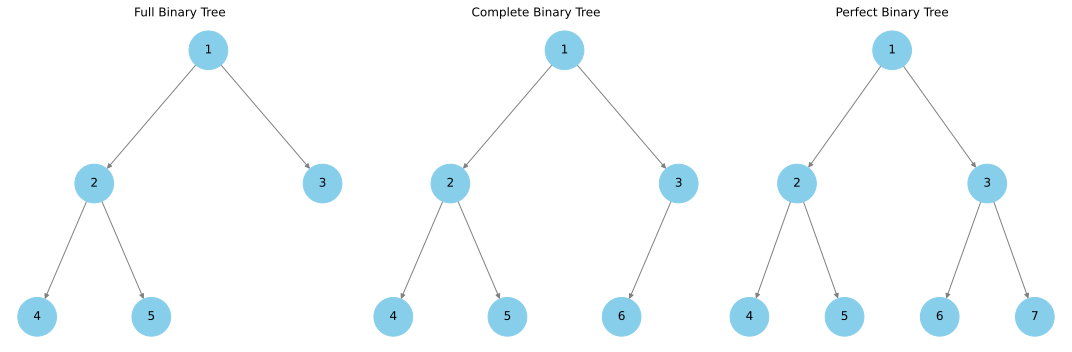

In [3]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

# Full binary tree example
full_binary_tree = [(1, 2), (1, 3), (2, 4), (2, 5)]
full_binary_tree_positions = {
    1: (0, 0),
    2: (-1, -1),
    3: (1, -1),
    4: (-1.5, -2),
    5: (-0.5, -2),
}
draw_tree(full_binary_tree, full_binary_tree_positions, "Full Binary Tree", axs[0])


# Complete binary tree example
complete_binary_tree = [(1, 2), (1, 3), (2, 4), (2, 5), (3, 6)]
complete_binary_tree_positions = {
    1: (0, 0),
    2: (-1, -1),
    3: (1, -1),
    4: (-1.5, -2),
    5: (-0.5, -2),
    6: (0.5, -2),
}
draw_tree(
    complete_binary_tree,
    complete_binary_tree_positions,
    "Complete Binary Tree",
    axs[1],
)

# Perfect binary tree example
perfect_binary_tree = [(1, 2), (1, 3), (2, 4), (2, 5), (3, 6), (3, 7)]
perfect_binary_tree_positions = {
    1: (0, 0),
    2: (-1, -1),
    3: (1, -1),
    4: (-1.5, -2),
    5: (-0.5, -2),
    6: (0.5, -2),
    7: (1.5, -2),
}
draw_tree(
    perfect_binary_tree,
    perfect_binary_tree_positions,
    "Perfect Binary Tree",
    axs[2],
)

plt.tight_layout()
plt.show()

## Example

Let's consider three running examples to help us understand the concepts of
trees and binary trees. We will use these examples throughout this chapter to
illustrate the different algorithms and data structures we will discuss.

The trees are ordered in terms of increasing complexity.

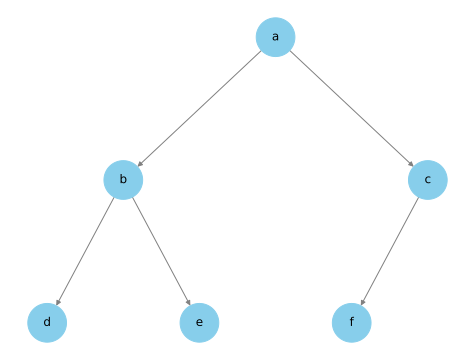

In [4]:
# Define the tree
T = nx.DiGraph()
edges = [
    ("a", "b"),
    ("a", "c"),
    ("b", "d"),
    ("b", "e"),
    ("c", "f"),
]
T.add_edges_from(edges)

# Define custom positions
pos = {
    "a": (0, 0),
    "b": (-1, -1),
    "c": (1, -1),
    "d": (-1.5, -2),
    "e": (-0.5, -2),
    "f": (0.5, -2),
}

# Draw the tree
nx.draw(
    T,
    pos,
    with_labels=True,
    node_color="skyblue",
    node_size=1500,
    edge_color="gray",
)

plt.show()

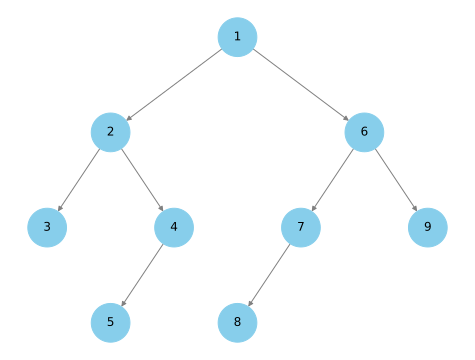

In [5]:
# Define the tree
T = nx.DiGraph()
edges = [
    ("1", "2"),
    ("1", "6"),
    ("2", "3"),
    ("2", "4"),
    ("6", "7"),
    ("6", "9"),
    ("4", "5"),
    ("7", "8"),
]

T.add_edges_from(edges)

# Define custom positions
pos = {
    "1": (0, 0),
    "2": (-2, -1),
    "3": (-3, -2),
    "4": (-1, -2),
    "5": (-2, -3),
    "6": (2, -1),
    "7": (1, -2),
    "8": (0, -3),
    "9": (3, -2),
}


# Draw the tree
nx.draw(
    T,
    pos,
    with_labels=True,
    node_color="skyblue",
    node_size=1500,
    edge_color="gray",
)

plt.show()

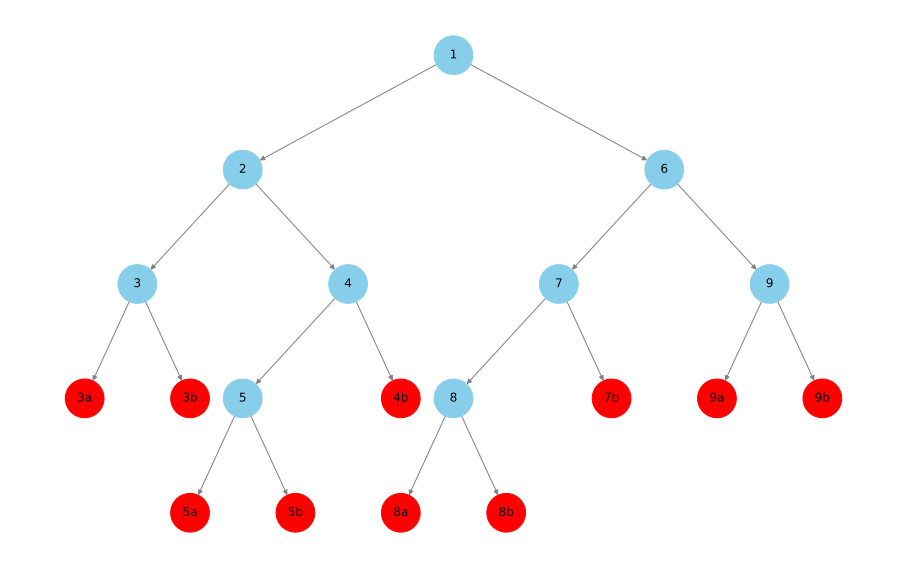

In [6]:
# Define the tree
T = nx.DiGraph()
edges = [
    ("1", "2"),
    ("1", "6"),
    ("2", "3"),
    ("2", "4"),
    ("6", "7"),
    ("6", "9"),
    ("4", "5"),
    ("7", "8"),
    # Add dummy nodes
    ("3", "3a"),
    ("3", "3b"),
    ("4", "4b"),
    ("5", "5a"),
    ("5", "5b"),
    ("7", "7b"),
    ("8", "8a"),
    ("8", "8b"),
    ("9", "9a"),
    ("9", "9b"),
]

T.add_edges_from(edges)

# Define custom positions
pos = {
    "1": (0, 0),
    "2": (-2, -1),
    "3": (-3, -2),
    "4": (-1, -2),
    "5": (-2, -3),
    "6": (2, -1),
    "7": (1, -2),
    "8": (0, -3),
    "9": (3, -2),
    # Positions for dummy nodes
    "3a": (-3.5, -3),
    "3b": (-2.5, -3),
    "4b": (-0.5, -3),
    "5a": (-2.5, -4),
    "5b": (-1.5, -4),
    "7b": (1.5, -3),
    "8a": (-0.5, -4),
    "8b": (0.5, -4),
    "9a": (2.5, -3),
    "9b": (3.5, -3),
}

node_colors = [
    "skyblue"
    if node not in ["3a", "3b", "4b", "5a", "5b", "7b", "8a", "8b", "9a", "9b"]
    else "red"
    for node in T.nodes
]

# Create a figure and an axes
fig, ax = plt.subplots(figsize=(16, 10))  # Adjust size as needed

# Draw the tree
nx.draw(
    T,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=1500,
    edge_color="gray",
    ax=ax,
)

plt.show()

## Common Notations

Given the tree defined above, let's introduce some tree-related notations using
this concrete example:

### Root

**Root**: In a rooted tree $T=(V, E, r)$, $r \in V$ is a distinguished vertex
referred to as the **root** of the tree. The root is the uppermost node in the
hierarchy and serves as the ancestor to all other nodes.

Using our earlier example, for the tree $T$, the root is $r = a$.

### Node

**Node**: In the rooted tree $T=(V, E, r)$, the elements of the set $V$ are
known as **nodes**. Nodes form the primary components of the tree. A special
type of node, a **leaf node**, is characterized by the lack of child nodes,
implying that it has no descendants.

From our previous example, the set of nodes is
$V = \left\{a, b, c, d, e, f\right\}$.

### Edge

**Edge**: An **edge** in a tree illustrates the relationship between two nodes
by connecting parent nodes to their offspring. Given the tree $T=(V, E)$, an
edge $e \in E$ is a link between two distinct nodes $x, y \in V$, represented as
$(x, y)$.

From our running example, the edges are

$$
E=\left\{(a, b), (a, c), (b, d) (b, e), (c, f)\right\}.
$$

### Child

**Child**: A **child** represents a node that shares an edge with a superior
node, known as its parent. For the rooted tree $T=(V, E, r)$, if $x, y \in V$
and $(x, y) \in E$, then $y$ is deemed a child of $x$.

In our running example, $b$ and $c$ are the children of root node $a$ while $d$
and $e$ are the children of node $b$.

### Parent

**Parent**: A **parent** is a node that connects to a lower-level node, or
child, via an edge. For a rooted tree $T=(V, E, r)$, if $x, y \in V$ and
$(x, y) \in E$, $x$ is the parent of $y$.

In our running example, $a$ is the parent of nodes $b, c$ but it is **_not_**
the parent of nodes $d, e, f$.

### Grandparent

**Grandparent**: A **grandparent** of a node in a tree is the parent of its
parent node. For a rooted tree $T=(V, E, r)$, if $x, y, z \in V$ and
$(x, y), (y, z) \in E$, then $x$ is the grandparent of $z$.

In our running example, $a$ is the grandparent of nodes $d, e, f$.

### Grandchild

**Grandchild**: A **grandchild** of a node in a tree is the child of its child
node. For a rooted tree $T=(V, E, r)$, if $x, y, z \in V$ and
$(x, y), (y, z) \in E$, then $z$ is the grandchild of $x$.

In our running example, $d, e, f$ are the grandchildren of node $a$.

### Subtree

**Subtree**: A **subtree** of a tree $T$ is a tree $S$ whose vertex and edge
sets are subsets of those of $T$. Formally, for a tree $T=(V, E)$ and its
subtree $S=(V_s, E_s)$, we have $V_s \subseteq V$ and $E_s \subseteq E$.

In our running example, the subtree rooted at node $b$ with nodes
$V_s=\{b, d, e\}$ and edges $E_s=\{(b, d), (b, e)\}$ is a subtree of $T$.

### Leaf Node

**Leaf Node**: A **leaf node** or terminal node refers to a node without
children. In the rooted tree $T=(V, E, r)$, a node $x \in V$ is a leaf node if
there doesn't exist a $y \in V$ such that $(x, y) \in E$.

In our running example, $d, e, f$ are leaf nodes.

### Depth

**Depth**: The **depth** of a node in a tree is the count of edges from the root
to that node. In a rooted tree $T=(V, E, r)$, the depth of a node $x$ is the
count of edges on the unique path from $r$ to $x$.

In our running example, the depth of node $d$ is 2 (via the path $a-b-d$).

Sometimes, it is also defined as the count of nodes on the path from the root to
the node. In this case, the depth of node $d$ is 3 (via the path $a-b-d$).

### Height

**Height**: The **height** of a node in a tree is the number of edges on the
longest path from that node to a leaf. The height of the tree itself is
equivalent to the height of its root node. In the rooted tree $T=(V, E, r)$, the
height of $T$ is the count of edges on the longest path from $r$ to a leaf node.

In our running example, the height of $T$ is 2 (via the path $a-b-d$ or $a-b-e$
or $a-c-f$).

Sometimes, it is also defined as the count of nodes on the longest path from the
node to a leaf. In this case, the height of $T$ is 3 (via the path $a-b-d$ or
$a-b-e$ or $a-c-f$).

## Intuition

**Trees** are used to model structures in various areas of computer science and
mathematics. Here is an example of how trees work in a real-world context:

Consider the structure of an **organization or company**. The CEO stands at the
top, directing various vice presidents who in turn manage several other
employees. This structure, from the CEO down to the individual contributors, can
be represented as a **tree**. The CEO serves as the root node, the vice
presidents are the children of the root, and the hierarchy continues down to the
employees, which can be leaf nodes if they don't have any subordinates. This
type of hierarchy structure is known as a **rooted tree**.

In the company tree, each person (node) has exactly one boss (parent), excluding
the CEO who doesn't report to anyone. This rule is similar to the properties of
a tree in graph theory, where each node has exactly one parent, except the root.

Also, each person in the organization can have multiple subordinates but they
have a direct reporting relationship only to their immediate boss. This also
mirrors a tree where a node can have multiple children, but each child has only
one parent.

The **depth** of a node in the company tree represents the number of levels an
employee is from the CEO, while the **height** of the tree is the number of
levels in the organizational hierarchy.

Another real-life example of a tree structure is the **file system** on your
computer. Folders can contain files or other folders and can be represented as a
tree. The root directory is the root of the tree, folders are internal nodes,
and files are leaves.

Let's create a hypothetical example of a file system using a tree structure:

Let's say we have a root directory called "Project". Under this directory, there
are three other directories: "Documents", "Source_Code", and "Images". The
"Documents" directory contains two files: "Report.docx" and "Summary.pdf". The
"Source_Code" directory has two other directories: "Python" and "JavaScript",
each containing some script files. Lastly, the "Images" directory contains one
file: "Logo.png".

This structure could be represented as follows:

```text
Project
├── Documents
│   ├── Report.docx
│   └── Summary.pdf
├── Source_Code
│   ├── Python
│   │   ├── script1.py
│   │   └── script2.py
│   └── JavaScript
│       ├── script1.js
│       └── script2.js
└── Images
    └── Logo.png
```

In this tree, `Project` is the **root**. It has three children: `Documents`,
`Source_Code`, and `Images`. The **edges** are represented by the lines
connecting the directories and files.

Each indent level represents a level in the tree, with `Project` at the root or
level 0, its immediate subdirectories at level 1, and so on. For example,
`Report.docx` and `Summary.pdf` are at level 2. The **depth** of `Report.docx`
or `Summary.pdf` is therefore 2, which is the number of edges on the path from
the root to the node.

A **leaf node** is a node without any children. In this file system,
`Report.docx`, `Summary.pdf`, `script1.py`, `script2.py`, `script1.js`,
`script2.js`, and `Logo.png` are leaf nodes because they don't contain any other
files or directories.

The **height** of this tree is the length of the longest path from the root to a
leaf. In this example, the height is 3 (traversing `Project` -> `Source_Code` ->
`Python` -> `script1.py` or `script2.py`).

The **subtree** rooted at `Source_Code` consists of `Source_Code` and everything
beneath it.

In this way, the concept of a tree is directly applicable to file systems and
directories in a computer.

## List of Lists Representation for Trees

In various scenarios, it is advantageous to represent a **tree data structure**
as a **list of lists**. This methodology leverages Python's inherent list
structure to construct a simple recursive data structure, making the
visualization and examination of the tree more straightforward.

Here's how a tree is represented in the list of lists form:

-   The tree is depicted as a list.
-   The first element of the list is the **root node's value**.
-   The second element of the list is another list, representing the **left
    subtree**.
-   The third element is another list that signifies the **right subtree**.

Let's consider a straightforward example:

Here's a simple **binary tree** structure:

```bash
     a
   /   \
  b     c
 / \   /
d   e f
```

Using the list of lists representation, we would represent this tree as follows:

```python
tree_list: List= [
    'a',   # root
    # left subtree
    [
        'b',  # root of left subtree
        [
            'd',  # left child of 'b'
            [],   # 'd' has no left child
            []    # 'd' has no right child
        ],
        [
            'e',  # right child of 'b'
            [],   # 'e' has no left child
            []    # 'e' has no right child
        ]
    ],
    # right subtree
    [
        'c',  # root of right subtree
        [
            'f',  # left child of 'c'
            [],   # 'f' has no left child
            []    # 'f' has no right child
        ],
        []     # 'c' has no right child
    ]
]
```

Or the less verbose version,

```python
root = ['a',
        ['b',
            ['d', [], []],
            ['e', [], []]
        ],
        ['c',
            ['f', [], []],
            []
        ]
    ]
```

-   The **root** of the tree is `a`, the first element of the list.
-   The second element of the list is another list, representing the left
    subtree with `b` as the root. This list follows the same pattern: `b` is the
    root, another list represents the left subtree rooted at `d`, and a third
    list represents the right subtree rooted at `e`.
-   The third element of the main list is a list representing the right subtree
    rooted at `c`. This list also adheres to the same pattern.

One of the benefits of this representation is its extensibility to trees with
more than two children per node. For trees with numerous subtrees, each subtree
would be depicted by an additional list.

Moreover, the list of lists representation provides an intuitive approach for
accessing and manipulating elements of the tree. For instance, `tree[0]`
retrieves the root of the tree, `tree[1]` fetches the left subtree, and
`tree[1][0]` gives the root of the left subtree. This recursive structure
simplifies the implementation of various tree operations, as the same methods
can be applied at each level of the tree.

In [7]:
tree_list: List= [
    'a',   # root
    # left subtree
    [
        'b',  # left subtree
        [
            'd',  # left child of 'b'
            [],   # no left child for 'd'
            []    # no right child for 'd'
        ],
        [
            'e',  # right child of 'b'
            [],   # no left child for 'e'
            []    # no right child for 'e'
        ]
    ],
    # right subtree
    [
        'c',  # right subtree
        [
            'f',  # left child of 'c'
            [],   # no left child for 'f'
            []    # no right child for 'f'
        ],
        []     # no right child for 'c'
    ]
]

In [8]:
# root
root = tree_list[0]
print(f"root={root}")

# left subtree of root
left_subtree = tree_list[1]
print(f"left_subtree={left_subtree}")

# right subtree of root
right_subtree = tree_list[2]
print(f"right_subtree={right_subtree}")

root=a

left_subtree=['b', ['d', [], []], ['e', [], []]]

right_subtree=['c', ['f', [], []], []]

### The Recursive Nature of List of Lists Representation

The **list of lists representation** of a tree illustrates the concept of a
**recursive data structure**. This approach interprets a list as a recursive
data structure as it comprises sublists, which are themselves considered as
individual trees.

The first element of the list serves as the tree's root, while the second and
third elements represent the left and right subtrees respectively. This pattern
recursively continues down the tree levels, with each subtree's first element
being its root, and its second and third elements being its left and right
subtrees respectively. This pattern persists until we reach the tree leaves
represented by empty lists.

This recursive structure facilitates the application of consistent operations or
processes at each tree level. For instance, to traverse the tree, the same
procedure is employed to visit each node and its children, irrespective of their
depth in the tree. The process remains constant due to the recursive structure
of the list of lists, enabling the same handling of the overall list and each of
its sublists.

### Binary Tree Representation using List of Lists

In [9]:
Node = Union[Union[str, int], List['Node'], List[None]]

def binary_tree(root: Node) -> Node:
    return [root, [], []]

def insert_left(root: Node, new_child: Union[str, int]) -> None:
    old_child = root.pop(1)  # this is ['b', [], []]
    if len(old_child) > 0:  # if the old child had children of its own
        root.insert(1, [new_child, old_child, []])
    else:
        root.insert(1, [new_child, [], []])

def insert_right(root: Node, new_child: Union[str, int]) -> None:
    old_child = root.pop(2)
    if len(old_child) > 0:
        root.insert(2, [new_child, [], old_child])
    else:
        root.insert(2, [new_child, [], []])

def get_root_value(root: Node) -> Union[str, int]:
    return root[0]

def set_root_value(root: Node, new_value: Union[str, int]) -> None:
    root[0] = new_value

def get_left_child(root: Node) -> Optional[Node]:
    return root[1]

def get_right_child(root: Node) -> Optional[Node]:
    return root[2]

def nodeInfo(node: Node) -> Tuple[str, Optional[Node], Optional[Node]]:
    # Return the string value and left/right nodes
    return (
        str(node[0]),
        node[1] if len(node) > 1 else None,
        node[2] if len(node) > 2 else None,
    )

### Building a Binary Tree

In [10]:
root = binary_tree(root="a")
print(root)

insert_left(root=root, new_child='b')
print(root)

insert_right(root=root, new_child='c')
print(root)

# grab the left child of root (which is 'b'), and add its children
b = get_left_child(root)
insert_left(b, 'd')
insert_right(b, 'e')

# grab the right child of root (which is 'c'), and add its left child
c = get_right_child(root)
insert_left(c, 'f')

print(root)

print_binary_tree(root, nodeInfo)

['a', [], []]

['a', ['b', [], []], []]

['a', ['b', [], []], ['c', [], []]]

['a', ['b', ['d', [], []], ['e', [], []]], ['c', ['f', [], []], []]]

      a
   __/ \_
  b      c
 / \    /
d   e  f


The process of building this binary tree is recursive in nature. If you notice,
the function `insert_left` and `insert_right` both receive a "root" node and
insert a new child beneath it. When we first start building the tree, this root
node is indeed the root of the entire tree ("a" in this case). However, as we
start to build up the tree, we begin passing these insert functions not the root
of the entire tree, but roots of smaller subtrees within the tree.

This is where the recursion comes in - the process of adding a node to the tree
can be defined in terms of adding a node to a smaller tree within the tree. This
"divide and conquer" strategy is the hallmark of recursion. The tree is composed
of smaller trees (its subtrees), which are themselves composed of even smaller
trees, and so on.

Let's break down how the tree is being built:

1. We start with root "a". At this point, the tree is just `["a", [], []]`.

2. We then add a left child "b" to "a". Now the tree looks like this:
   `["a", ["b", [], []], []]`. In this step, "a" is the root of the whole tree.

3. Then we add a right child "c" to "a". Now the tree looks like this:
   `["a", ["b", [], []], ["c", [], []]]`. "a" is still the root of the whole
   tree.

4. Now we want to add children to "b". At this point, "b" is the root of its own
   subtree, and we use it as the root in our `insert_left` and `insert_right`
   calls. We add "d" as the left child of "b" and "e" as the right child of "b".
   Now our tree looks like this:
   `["a", ["b", ["d", [], []], ["e", [], []]], ["c", [], []]]`.

5. Similarly, we then add "f" as the left child of "c". Now "c" is the root of
   its own subtree. Our final tree looks like this:
   `["a", ["b", ["d", [], []], ["e", [], []]], ["c", ["f", [], []], []]]`.

So, the process of building the tree is recursive because each subtree is a tree
in its own right, and the process of adding a child to a tree is the same
regardless of whether that tree is the entire tree or just a subtree. This
recursive nature is facilitated by the list of lists representation, where each
nested list is a subtree.

This building of tree has a name, it's called
[**level-order traversal**](https://www.geeksforgeeks.org/level-order-tree-traversal).
We can of course build the tree in other ways, for example, we can build it in
[**pre-order traversal**](https://www.geeksforgeeks.org/tree-traversals-inorder-preorder-and-postorder/),
which we will talk about later.

We can also build the tree below in the same manner.

```bash
      1
   __/ \_
  2      6
 / \    / \
3   4  7   9
   /  /
  5  8
```

In [11]:
root = binary_tree(1)

# inserting nodes at the second level
insert_left(root, 2)
insert_right(root, 6)

# grabbing the left and right children of root (which are 2 and 6)
left = get_left_child(root)
right = get_right_child(root)

# inserting children of 2 (which are 3 and 4)
insert_left(left, 3)
insert_right(left, 4)

# inserting children of 6 (which are 7 and 9)
insert_left(right, 7)
insert_right(right, 9)

# grabbing the right child of 2 (which is 4), and adding its child
four = get_right_child(left)
insert_left(four, 5)

# grabbing the left child of 6 (which is 7), and adding its child
seven = get_left_child(right)
insert_left(seven, 8)

# print the final tree
print_binary_tree(root, nodeInfo)

      1
   __/ \_
  2      6
 / \    / \
3   4  7   9
   /  /
  5  8


We can also use our helper function to obtain any subtree. For instance, if I
want the right subtree of the root, I can do this:

In [12]:
right = get_right_child(root)
print(right)
print_binary_tree(right, nodeInfo)

right = get_right_child(right)
print(right)
print_binary_tree(right, nodeInfo)

[6, [7, [8, [], []], []], [9, [], []]]

    6
   / \
  7   9
 /
8


[9, [], []]

9


## Node and References Representation for Trees

In data structures, another common method of representing binary trees is the
Node and References model. In this approach, a node in the tree is a
self-referential data structure, as it contains references to its children nodes
(if any). This method provides a more intuitive way of manipulating binary trees
and is widely used in practical programming.

### Binary Tree Representation using Node and References

The Node and References model builds a tree from the ground up by linking
together individual nodes. Each node has its own identity, represented as a data
structure or object containing at least two fields:

1. **Data field:** Stores the value or data associated with the node.
2. **References:** Point to the node's child nodes (usually left and right child
   for binary trees).

For example, in a binary tree, each node is connected to at most two other
nodes, typically referred to as the left child and the right child.

In the Python implementation, the `BinaryTreeNode` class is used to create nodes, each
having a value (`val`) and references to their left and right child nodes
(`left` and `right`). The `BinaryTree` class represents the entire tree, holding
a reference to the root node.

In [13]:
T = TypeVar("T")  # This is a node type hint, i.e. the val type the node stores

@dataclass
class BinaryTreeNode(Generic[T]):
    """This class represents a node in a binary tree.

    Parameters
    ----------
    val : T
        The val stored at this node. The type of the val is determined by the
        type variable `T`, which can be specified when creating a BinaryTreeNode. For
        example, BinaryTreeNode[int] would create a tree node that stores an integer.
    left : Optional[BinaryTreeNode[T]]
        The left child of this node. This is another BinaryTreeNode object. If the node
        does not have a left child, this should be None.
    right : Optional[BinaryTreeNode[T]]
        The right child of this node. This is another BinaryTreeNode object. If the node
        does not have a right child, this should be None.
    """

    val: T
    left: Optional[BinaryTreeNode[T]] = None
    right: Optional[BinaryTreeNode[T]] = None

    def __str__(self) -> str:
        """Returns a string representation of the BinaryTreeNode object.

        Returns
        -------
        str
            A string representation of the BinaryTreeNode object.
        """
        return f"BinaryTreeNode({self.val})"

    def __repr__(self) -> str:
        """Returns a formal string representation of the BinaryTreeNode object,
        useful for debugging.

        Returns
        -------
        str
            A formal string representation of the BinaryTreeNode object.
        """
        return f"BinaryTreeNode(val={self.val}, left={repr(self.left)}, right={repr(self.right)})"

@dataclass
class BinaryTree(Generic[T]):
    """
    Class to represent a binary tree.

    Attributes
    ----------
    root : Optional[BinaryTreeNode[T]]
        The root node of the binary tree.
    """

    root: Optional[BinaryTreeNode[T]]

    def insert_left(self, new_child: T) -> None:
        """
        Inserts a new node to the left of the root node.

        If there's already a node on the left, the new node is inserted above it
        and the existing node becomes the left child of the new node.

        Parameters
        ----------
        new_child : T
            The value to be stored in the new node.
        """
        if self.root is None:
            self.root = BinaryTreeNode(new_child)
        else:
            old_child = self.root.left
            if old_child:
                self.root.left = BinaryTreeNode(new_child, left=old_child)
            else:
                self.root.left = BinaryTreeNode(new_child)

    def insert_right(self, new_child: T) -> None:
        """
        Inserts a new node to the right of the root node.

        If there's already a node on the right, the new node is inserted above it and
        the existing node becomes the right child of the new node.

        Parameters
        ----------
        new_child : T
            The value to be stored in the new node.
        """
        if self.root is None:
            self.root = BinaryTreeNode(new_child)
        else:
            old_child = self.root.right
            if old_child:
                self.root.right = BinaryTreeNode(new_child, right=old_child)
            else:
                self.root.right = BinaryTreeNode(new_child)

    def get_root_value(self) -> Optional[T]:
        """
        Retrieves the value stored at the root node.

        Returns
        -------
        Optional[T]
            The value stored at the root node or None if the tree is empty.
        """
        return self.root.val if self.root else None

    def set_root_value(self, new_value: T) -> None:
        """
        Sets a new value for the root node.

        Parameters
        ----------
        new_value : T
            The new value to be stored at the root node.
        """
        if self.root:
            self.root.val = new_value

    def get_left_child(self) -> Optional[BinaryTreeNode[T]]:
        """
        Retrieves the left child of the root node.

        Returns
        -------
        Optional[BinaryTreeNode[T]]
            The left child of the root node or None if the tree is empty or if
            the root node has no left child.
        """
        return self.root.left if self.root else None

    def get_right_child(self) -> Optional[BinaryTreeNode[T]]:
        """
        Retrieves the right child of the root node.

        Returns
        -------
        Optional[BinaryTreeNode[T]]
            The right child of the root node or None if the tree is empty or if
            the root node has no right child.
        """
        return self.root.right if self.root else None

    def __str__(self) -> str:
        """Draws the binary tree."""
        lines = print_binary_tree(
            self.root, node_info=lambda n: (str(n.value), n.left, n.right), is_top=False
        )
        return "\n".join(lines)

    def __repr__(self) -> str:
        """Formal string representation of the binary tree."""
        return str(self)

### Building a Binary Tree

The tree is constructed by creating nodes and linking them together through
their left and right references. For instance, consider the following steps to
create a binary tree:

1. Create an instance of `BinaryTree` with the root node's value.
2. Insert new nodes as left or right child nodes by creating `BinaryTreeNode`
   instances and linking them to their parent nodes through the `insert_left`
   and `insert_right` methods.
3. To insert additional child nodes, access the parent node's reference (e.g.,
   `tree.root.left`) and assign new `BinaryTreeNode` instances.

We can build the same tree as before using the `BinaryTree` class.

In [14]:
# create the binary tree
tree = BinaryTree(None)

# insert the root value
tree.root = BinaryTreeNode(1)

# insert left and right children for root
tree.insert_left(2)
tree.insert_right(6)

# insert children for 2
tree.root.left.left = BinaryTreeNode(3)
tree.root.left.right = BinaryTreeNode(4)

# insert children for 6
tree.root.right.left = BinaryTreeNode(7)
tree.root.right.right = BinaryTreeNode(9)

# insert child for 4
tree.root.left.right.left = BinaryTreeNode(5)

# insert child for 7
tree.root.right.left.left = BinaryTreeNode(8)

# print the tree
print(tree)

<repr-error "'BinaryTreeNode' object has no attribute 'value'">

In this example, the `insert_left` and `insert_right` methods are used to insert
nodes to the left and right of the root node, respectively. If there's already a
node in the position, the new node is inserted above it, and the existing node
becomes the child of the new node.

The Node and References model provides a solid basis for the implementation and
manipulation of tree data structures in practical programming. By understanding
this model, you'll have a good foundation for implementing more complex
tree-based algorithms and data structures.

## Convention for Representing Trees

In coding interviews, the focus often lies on the manipulation and traversal of
the tree, rather than the construction of the tree itself. It is therefore
typical to represent trees using only a `BinaryTreeNode` class, and use this to build
the tree in a systematic and efficient manner. This provides a simple,
streamlined approach that abstracts the process of creating individual nodes and
linking them together.

We will see later how with just a `BinaryTreeNode` class, we can build the same tree
in a more systematic and efficient manner.

## Summary

We are far from done here, the main bulk of tree related operations involve some
kind of traversal. We will cover that in the next section.

## References and Further Readings

- **[Tech Interview Handbook - Yang Shun](https://www.techinterviewhandbook.org/algorithms/tree/)**
    - As well as all the learning resources he recommended in his article.
- **[Leetcode Card: Binary Tree](https://leetcode.com/explore/learn/card/data-structure-tree/)**